# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

In [2]:
# descomentar si no estan instaladas
# ! pip install open-clip-torch matplotlib scikit-learn pillow scipy

## 1. Cargar el modelo CLIP

Usamos ViT-B/32 de OpenAI con la librería `open_clip`. Este modelo tiene dos encoders separados (uno para texto, otro para imagen) que producen vectores de **512 dimensiones** en un espacio compartido.

La idea es que pares relacionados (ej: una foto de un perro y el texto "a dog") tengan vectores cercanos en ese espacio.

In [3]:
import open_clip
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import re

modelo, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
tokenizer = open_clip.get_tokenizer("ViT-B-32")
modelo.eval()

print("CLIP cargado")

c:\Users\ladol\anaconda3\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP cargado


## 2. Cargar las imágenes

Tenemos 10 imágenes locales variadas: perros, gatos, insectos, flores, fruta y una playa. Ninguna tiene etiquetas ni descripciones — CLIP va a trabajar directamente con los píxeles.

In [4]:
carpeta = "imagenes"
imagenes = {}

archivos = sorted(
    [f for f in os.listdir(carpeta) if f.lower().endswith((".jpg", ".jpeg", ".png"))],
    key=lambda x: int(re.search(r'\d+', x).group())
)

for archivo in archivos:
    ruta = os.path.join(carpeta, archivo)
    img = Image.open(ruta).convert("RGB")
    nombre = os.path.splitext(archivo)[0]
    imagenes[nombre] = img
    print(f"{nombre} - {img.size}")

print(f"\nTotal: {len(imagenes)} imágenes")

img_1 - (739, 415)
img_2 - (554, 554)
img_3 - (640, 480)
img_4 - (1200, 900)
img_5 - (1170, 778)
img_6 - (1600, 900)
img_7 - (515, 388)
img_8 - (8256, 5504)
img_9 - (640, 480)
img_10 - (678, 452)

Total: 10 imágenes


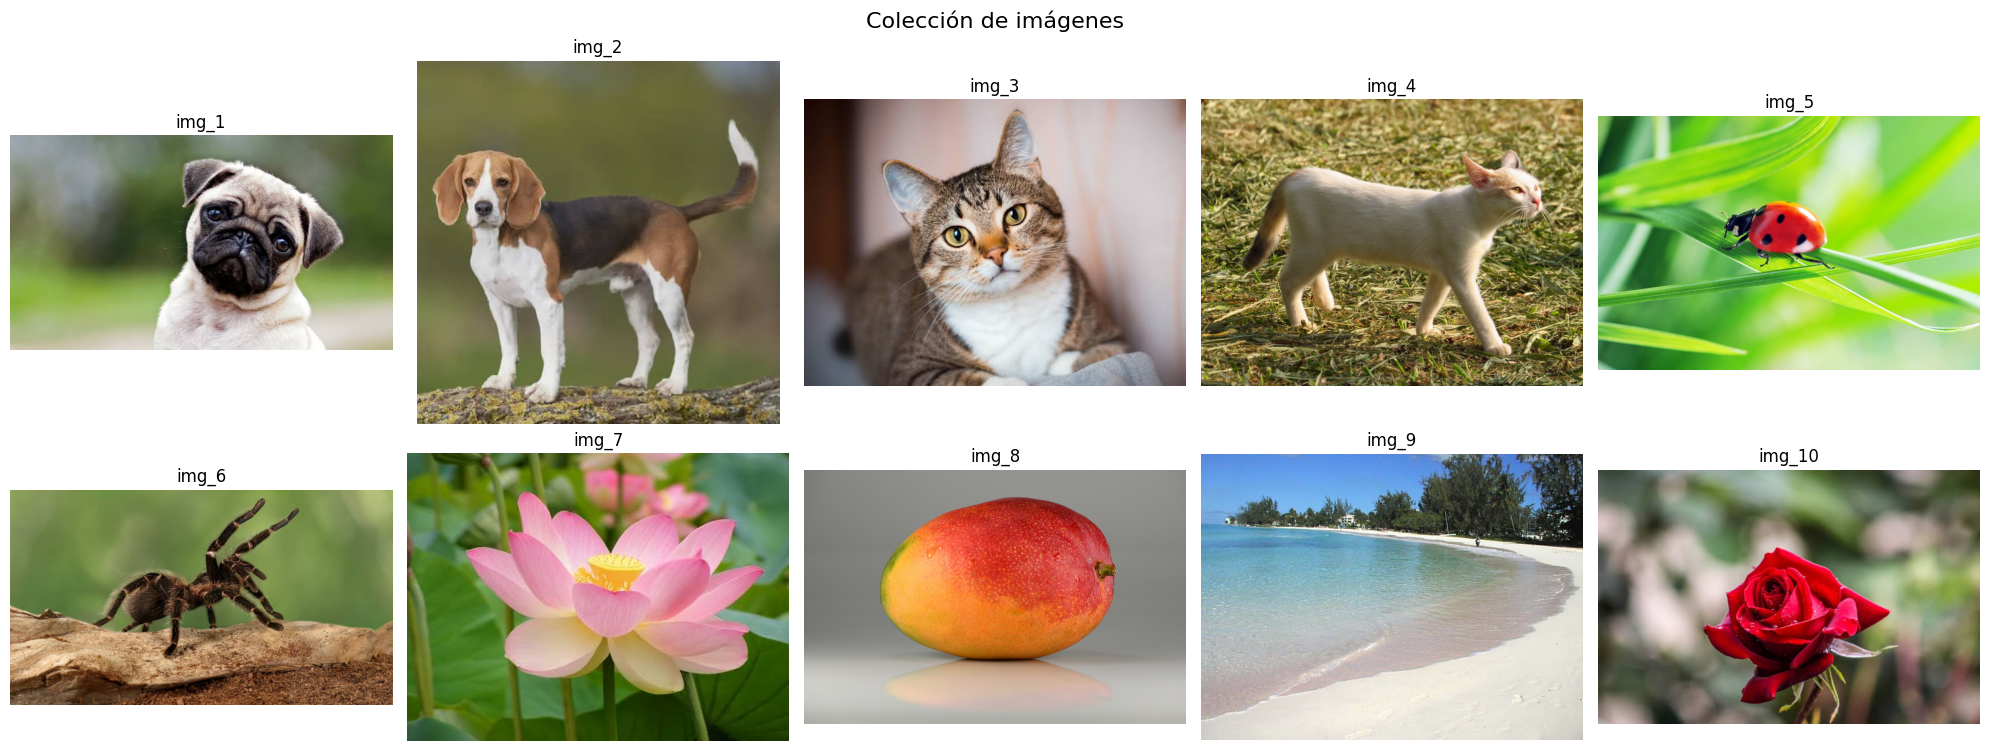

In [5]:
import math

n = len(imagenes)
cols = 5
filas = math.ceil(n / cols)

fig, axes = plt.subplots(filas, cols, figsize=(4 * cols, 4 * filas))
axes = axes.flatten()

for idx, (nombre, img) in enumerate(imagenes.items()):
    axes[idx].imshow(img)
    axes[idx].set_title(nombre, fontsize=12)
    axes[idx].axis("off")

for i in range(n, len(axes)):
    axes[i].axis("off")

plt.suptitle("Colección de imágenes", fontsize=16)
plt.tight_layout()
plt.show()

## 3. Obtener embeddings (Paso 1)

Codificamos cada imagen y cada texto con CLIP. Cada uno produce un vector de 512 dimensiones. Normalizamos los vectores para que la similitud coseno sea simplemente el producto punto.

In [6]:
# embeddings de imagenes
embs_img = {}

with torch.no_grad():
    for nombre, img in imagenes.items():
        tensor = preprocess(img).unsqueeze(0)
        vec = modelo.encode_image(tensor)
        vec = vec / vec.norm(dim=-1, keepdim=True)
        embs_img[nombre] = vec.squeeze().numpy()

print(f"Imagenes codificadas: {len(embs_img)}")
print(f"Dimensión de cada vector: {list(embs_img.values())[0].shape[0]}")

Imagenes codificadas: 10
Dimensión de cada vector: 512


Ahora los textos. Definimos una descripción corta para cada imagen — no tienen que ser perfectas, la idea es ver cómo CLIP relaciona conceptos entre modalidades.

In [7]:
textos = [
    "a pug dog",
    "a beagle standing",
    "a tabby cat",
    "a white cat walking on grass",
    "a ladybug on a green leaf",
    "a large tarantula spider",
    "a pink lotus flower",
    "a ripe mango fruit",
    "a tropical beach with clear water",
    "a red rose"
]

In [8]:
embs_txt = {}

with torch.no_grad():
    for t in textos:
        tokens = tokenizer([t])
        vec = modelo.encode_text(tokens)
        vec = vec / vec.norm(dim=-1, keepdim=True)
        embs_txt[t] = vec.squeeze().numpy()

print(f"Textos codificados: {len(embs_txt)}")
print(f"Dimensión de cada vector: {list(embs_txt.values())[0].shape[0]}")

Textos codificados: 10
Dimensión de cada vector: 512


## 4. Verificar que comparten el mismo espacio (Paso 2)

Si imagen y texto producen vectores de la misma dimensión, podemos calcular el producto punto directamente entre ellos. Esto confirma que ambas modalidades están en el mismo espacio vectorial y son comparables.

In [9]:
nombres_img = list(embs_img.keys())
nombres_txt = list(embs_txt.keys())

In [10]:
vec_img = embs_img[nombres_img[0]]
vec_txt = embs_txt[nombres_txt[0]]

In [11]:
print(f"Dimensión imagen ({nombres_img[0]}): {vec_img.shape}")

Dimensión imagen (img_1): (512,)


In [12]:
print(f"Dimensión texto  (\"{nombres_txt[0]}\"): {vec_txt.shape}")

Dimensión texto  ("a pug dog"): (512,)


In [15]:
print(f"¿Misma dimensión? {vec_img.shape == vec_txt.shape}")

¿Misma dimensión? True


In [17]:
print(f"\nProducto punto entre ellos: {np.dot(vec_img, vec_txt):.4f}")


Producto punto entre ellos: 0.3072


Esto confirma que ambos encoders (texto e imagen) proyectan al mismo espacio de 512 dimensiones, lo que hace posible compararlos directamente.

Veamos también la norma de los vectores. Como los normalizamos, todos deberían tener norma ≈ 1, lo que confirma que el producto punto equivale a la similitud coseno.

In [18]:
print("Normas de vectores de imagen:")
for nombre in nombres_img[:3]:
    print(f"  {nombre}: {np.linalg.norm(embs_img[nombre]):.6f}")

Normas de vectores de imagen:
  img_1: 1.000000
  img_2: 1.000000
  img_3: 1.000000


In [19]:
print("Normas de vectores de texto:")
for t in nombres_txt[:3]:
    print(f"  \"{t}\": {np.linalg.norm(embs_txt[t]):.6f}")

Normas de vectores de texto:
  "a pug dog": 1.000000
  "a beagle standing": 1.000000
  "a tabby cat": 1.000000


Al ser todos ≈ 1.0 confirmamos que la normalización funcionó y que el producto punto equivale directamente a la similitud coseno.

## 5. Proyección a 2D (Paso 3)

Los vectores de CLIP tienen 512 dimensiones, así que no los podemos graficar directamente. Usamos **PCA** y **t-SNE** para reducirlos a 2D y ver si textos e imágenes relacionados quedan cerca en el plano.

### 5.1 PCA

In [20]:
from sklearn.decomposition import PCA

# juntamos todos los vectores en una sola matriz
todos_vecs = np.vstack([
    np.array([embs_img[n] for n in nombres_img]),
    np.array([embs_txt[t] for t in nombres_txt])
])

In [21]:
etiquetas = nombres_img + [f'"{t}"' for t in nombres_txt]
tipos = ["imagen"] * len(nombres_img) + ["texto"] * len(nombres_txt)

In [22]:
# PCA a 2 componentes
pca = PCA(n_components=2)
coords_pca = pca.fit_transform(todos_vecs)

print(f"Varianza explicada por PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Varianza explicada por PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total: {sum(pca.explained_variance_ratio_):.2%}")

Varianza explicada por PC1: 42.52%
Varianza explicada por PC2: 8.01%
Total: 50.52%


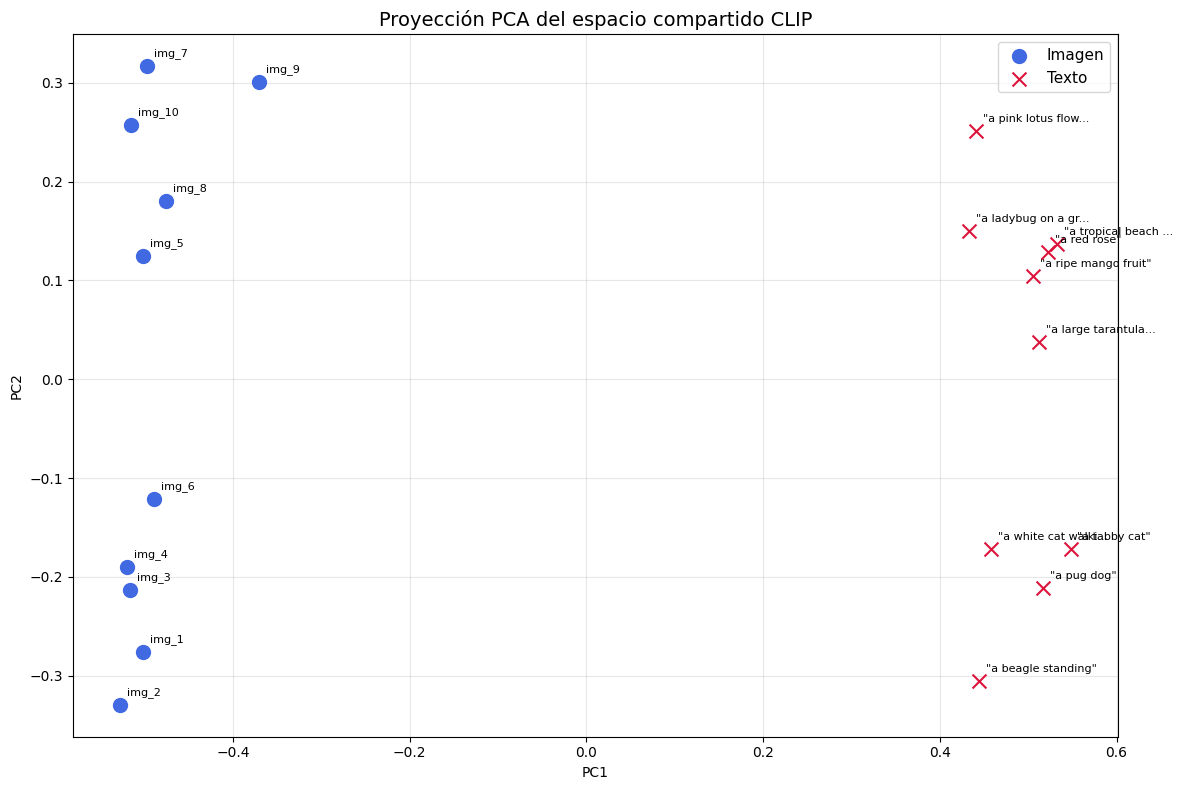

In [23]:
plt.figure(figsize=(12, 8))

for i, tipo in enumerate(tipos):
    x, y = coords_pca[i]
    color = "royalblue" if tipo == "imagen" else "crimson"
    marker = "o" if tipo == "imagen" else "x"
    plt.scatter(x, y, c=color, marker=marker, s=100, zorder=3)
    
    # acortar la etiqueta para que no se amontonen
    label = etiquetas[i]
    if len(label) > 20:
        label = label[:18] + "..."
    plt.annotate(label, (x, y), fontsize=8, ha="left", va="bottom",
                 xytext=(5, 5), textcoords="offset points")

# leyenda manual
plt.scatter([], [], c="royalblue", marker="o", label="Imagen", s=100)
plt.scatter([], [], c="crimson", marker="x", label="Texto", s=100)
plt.legend(fontsize=11)

plt.title("Proyección PCA del espacio compartido CLIP", fontsize=14)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Los puntos no forman clusters claros. Esto es esperado: con solo 20 vectores (10 imágenes + 10 textos) en un espacio original de 512 dimensiones, PCA con 2 componentes captura muy poca varianza y pierde la mayoría de la estructura. Los emparejamientos reales sí existen en las 512 dimensiones, pero se pierden al comprimir tanto.

### 5.2 t-SNE

PCA es lineal y a veces no captura bien las relaciones locales. t-SNE es no lineal y busca preservar las distancias entre vecinos cercanos, así que puede mostrar mejor los agrupamientos semánticos.

c:\Users\ladol\anaconda3\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


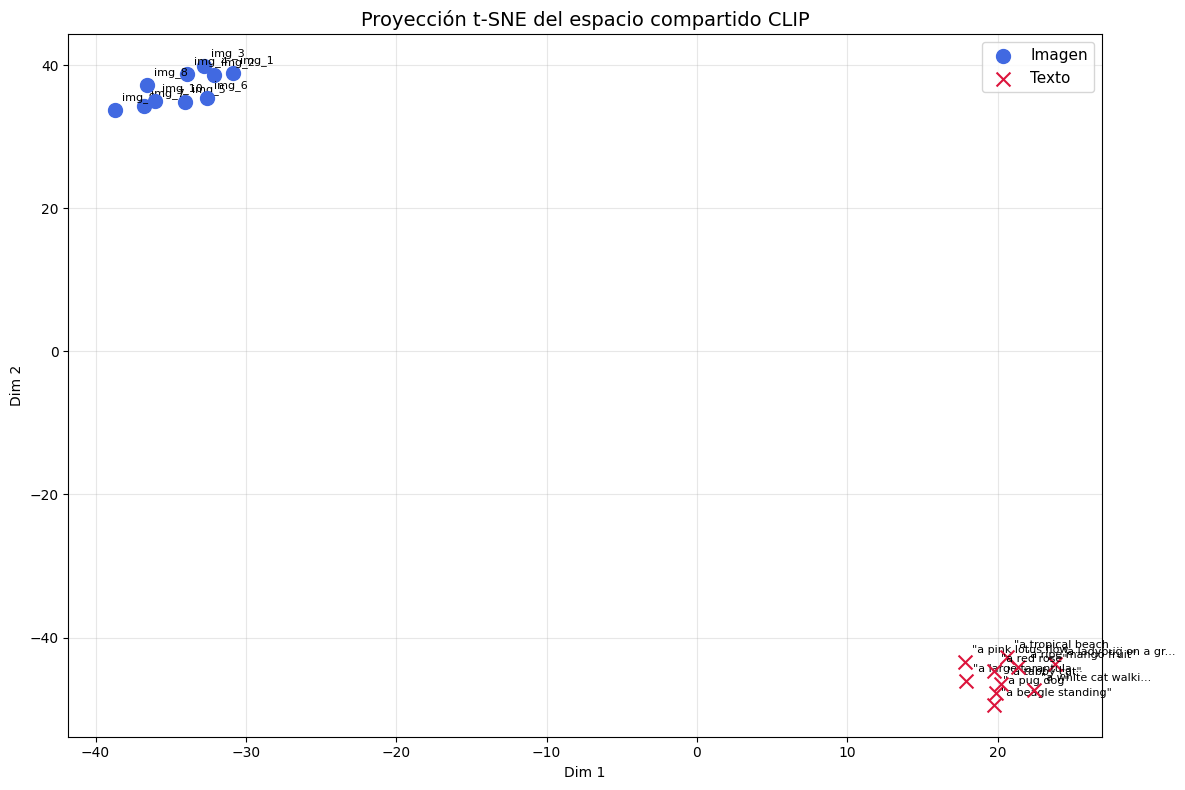

In [24]:
from sklearn.manifold import TSNE

# perplexity tiene que ser menor que el num de muestras
tsne = TSNE(n_components=2, perplexity=5, random_state=42, n_iter=1000)
coords_tsne = tsne.fit_transform(todos_vecs)

plt.figure(figsize=(12, 8))

for i, tipo in enumerate(tipos):
    x, y = coords_tsne[i]
    color = "royalblue" if tipo == "imagen" else "crimson"
    marker = "o" if tipo == "imagen" else "x"
    plt.scatter(x, y, c=color, marker=marker, s=100, zorder=3)
    
    label = etiquetas[i]
    if len(label) > 20:
        label = label[:18] + "..."
    plt.annotate(label, (x, y), fontsize=8, ha="left", va="bottom",
                 xytext=(5, 5), textcoords="offset points")

plt.scatter([], [], c="royalblue", marker="o", label="Imagen", s=100)
plt.scatter([], [], c="crimson", marker="x", label="Texto", s=100)
plt.legend(fontsize=11)

plt.title("Proyección t-SNE del espacio compartido CLIP", fontsize=14)
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

t-SNE tampoco logra formar agrupamientos claros. Con tan pocas muestras, no hay suficientes vecinos para que el algoritmo identifique estructura local. Por eso el heatmap de similitud es más informativo en este caso — muestra las relaciones directamente sin necesidad de reducir dimensiones.

### 5.3 Mejora: visualización con emparejamientos

Las gráficas anteriores no muestran clusters porque solo hay 20 puntos. Pero podemos mejorar la visualización de dos formas: coloreando por categoría semántica y dibujando líneas entre cada imagen y su texto correspondiente. Así se ve la estructura que sí existe pero que PCA/t-SNE no pueden mostrar con tan pocos datos.

In [36]:
categorias = {
    "img_1": "perro", "img_2": "perro",
    "img_3": "gato", "img_4": "gato",
    "img_5": "insecto", "img_6": "insecto",
    "img_7": "flor", "img_10": "flor",
    "img_8": "fruta",
    "img_9": "playa"
}

In [37]:
# cada texto corresponde a una imagen por posicion
pares_txt = {
    textos[0]: "perro", textos[1]: "perro",
    textos[2]: "gato", textos[3]: "gato",
    textos[4]: "insecto", textos[5]: "insecto",
    textos[6]: "flor", textos[9]: "flor",
    textos[7]: "fruta",
    textos[8]: "playa"
}

In [38]:
colores_cat = {
    "perro": "#e74c3c",
    "gato": "#3498db",
    "insecto": "#2ecc71",
    "flor": "#e67e22",
    "fruta": "#9b59b6",
    "playa": "#1abc9c"
}

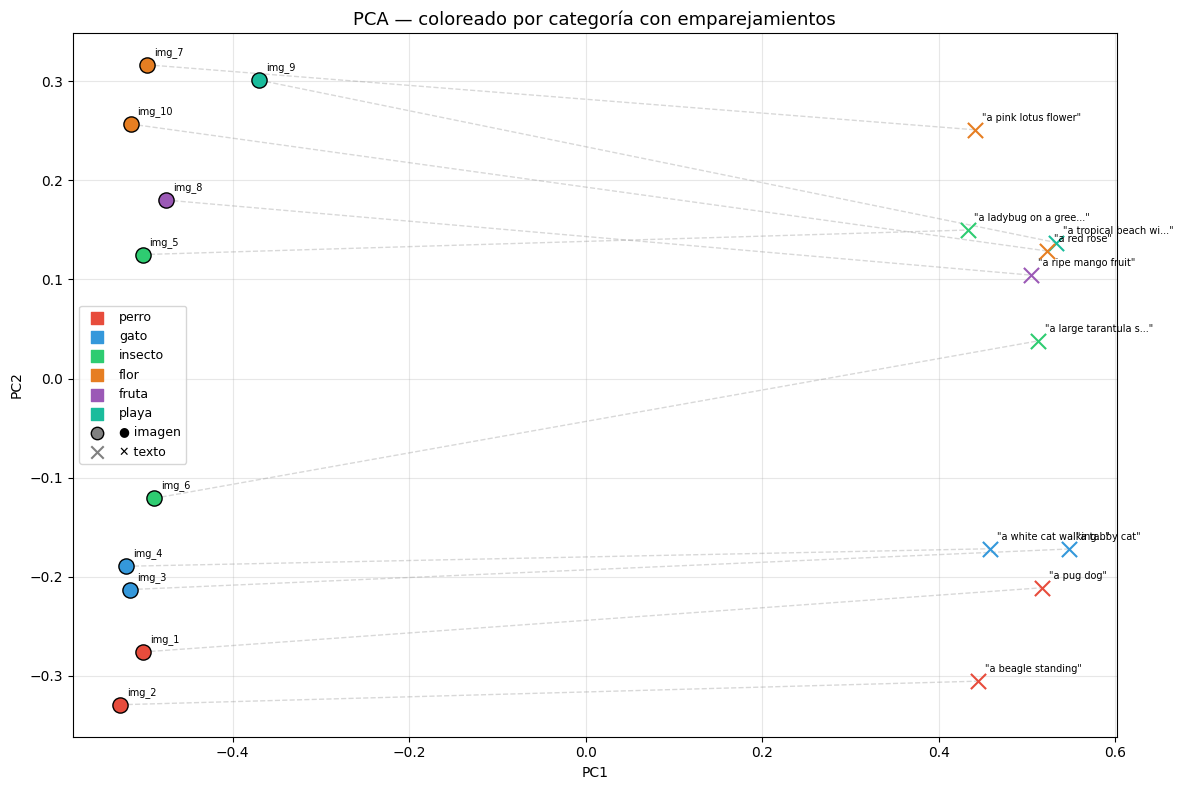

In [45]:
plt.figure(figsize=(12, 8))

for idx_img in range(len(nombres_img)):
    idx_txt = len(nombres_img) + idx_img
    plt.plot([coords_pca[idx_img, 0], coords_pca[idx_txt, 0]],
             [coords_pca[idx_img, 1], coords_pca[idx_txt, 1]],
             color="gray", alpha=0.3, linestyle="--", linewidth=1)

for i, nombre in enumerate(nombres_img):
    cat = categorias[nombre]
    plt.scatter(coords_pca[i, 0], coords_pca[i, 1],
                c=colores_cat[cat], marker="o", s=120, zorder=3, edgecolors="black")
    plt.annotate(nombre, (coords_pca[i, 0], coords_pca[i, 1]),
                 fontsize=7, ha="left", va="bottom", xytext=(5, 5),
                 textcoords="offset points")

for j, t in enumerate(nombres_txt):
    idx = len(nombres_img) + j
    cat = pares_txt[textos[j]]
    plt.scatter(coords_pca[idx, 0], coords_pca[idx, 1],
                c=colores_cat[cat], marker="x", s=120, zorder=3)
    label = f'"{textos[j]}"'
    if len(label) > 22:
        label = label[:20] + '..."'
    plt.annotate(label, (coords_pca[idx, 0], coords_pca[idx, 1]),
                 fontsize=7, ha="left", va="bottom", xytext=(5, 5),
                 textcoords="offset points")

for cat, color in colores_cat.items():
    plt.scatter([], [], c=color, marker="s", label=cat, s=80)
plt.scatter([], [], c="gray", marker="o", label="● imagen", s=80, edgecolors="black")
plt.scatter([], [], c="gray", marker="x", label="✕ texto", s=80)
plt.legend(fontsize=9, loc="best")

plt.title("PCA — coloreado por categoría con emparejamientos", fontsize=13)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

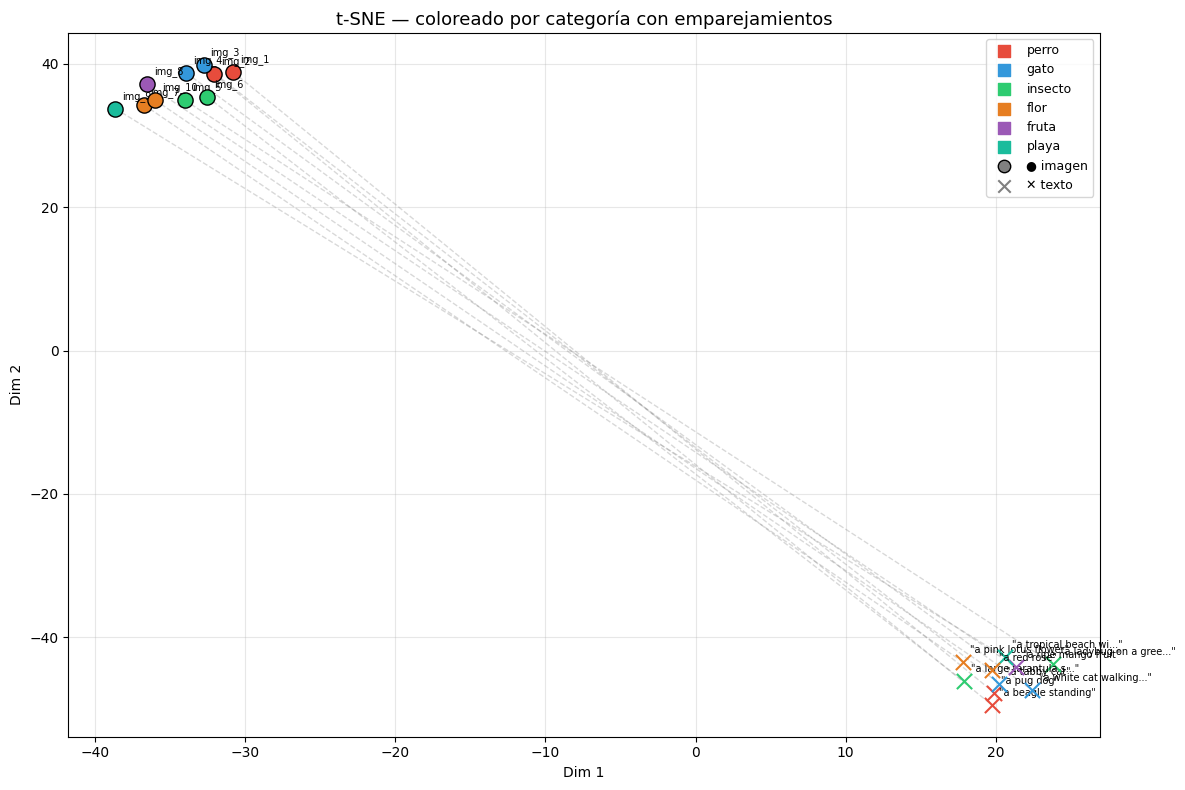

In [46]:
plt.figure(figsize=(12, 8))

for idx_img in range(len(nombres_img)):
    idx_txt = len(nombres_img) + idx_img
    plt.plot([coords_tsne[idx_img, 0], coords_tsne[idx_txt, 0]],
             [coords_tsne[idx_img, 1], coords_tsne[idx_txt, 1]],
             color="gray", alpha=0.3, linestyle="--", linewidth=1)

for i, nombre in enumerate(nombres_img):
    cat = categorias[nombre]
    plt.scatter(coords_tsne[i, 0], coords_tsne[i, 1],
                c=colores_cat[cat], marker="o", s=120, zorder=3, edgecolors="black")
    plt.annotate(nombre, (coords_tsne[i, 0], coords_tsne[i, 1]),
                 fontsize=7, ha="left", va="bottom", xytext=(5, 5),
                 textcoords="offset points")

for j, t in enumerate(nombres_txt):
    idx = len(nombres_img) + j
    cat = pares_txt[textos[j]]
    plt.scatter(coords_tsne[idx, 0], coords_tsne[idx, 1],
                c=colores_cat[cat], marker="x", s=120, zorder=3)
    label = f'"{textos[j]}"'
    if len(label) > 22:
        label = label[:20] + '..."'
    plt.annotate(label, (coords_tsne[idx, 0], coords_tsne[idx, 1]),
                 fontsize=7, ha="left", va="bottom", xytext=(5, 5),
                 textcoords="offset points")

for cat, color in colores_cat.items():
    plt.scatter([], [], c=color, marker="s", label=cat, s=80)
plt.scatter([], [], c="gray", marker="o", label="● imagen", s=80, edgecolors="black")
plt.scatter([], [], c="gray", marker="x", label="✕ texto", s=80)
plt.legend(fontsize=9, loc="best")

plt.title("t-SNE — coloreado por categoría con emparejamientos", fontsize=13)
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Heatmap de similitud

Con solo 10+10 puntos las proyecciones 2D a veces no muestran clusters claros. Un heatmap de similitud coseno es más directo: muestra exactamente qué tan parecido es cada texto a cada imagen.

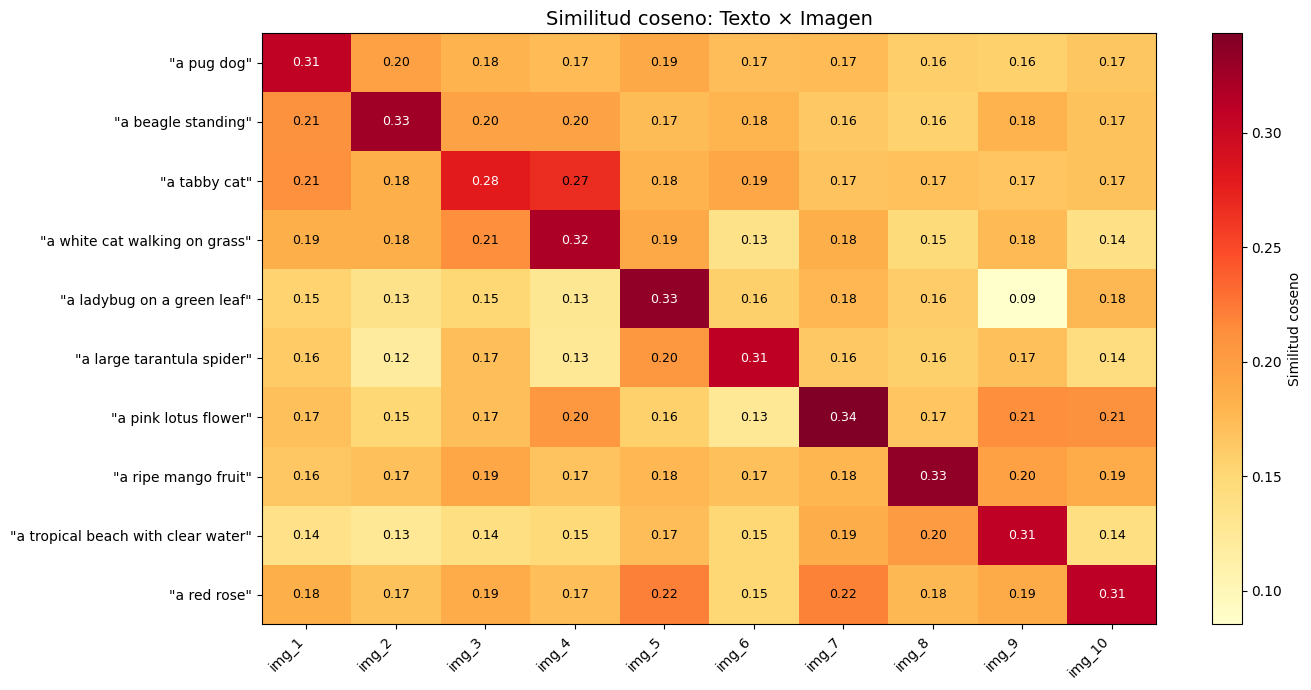

In [25]:
mat_img = np.array([embs_img[n] for n in nombres_img])
mat_txt = np.array([embs_txt[t] for t in nombres_txt])

# similitud texto x imagen
matriz_sim = mat_txt @ mat_img.T

plt.figure(figsize=(14, 7))
im = plt.imshow(matriz_sim, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, label="Similitud coseno")

plt.xticks(range(len(nombres_img)), nombres_img, rotation=45, ha="right")
plt.yticks(range(len(nombres_txt)), [f'"{t}"' for t in nombres_txt])

for i in range(len(nombres_txt)):
    for j in range(len(nombres_img)):
        color = "white" if matriz_sim[i, j] > 0.27 else "black"
        plt.text(j, i, f"{matriz_sim[i, j]:.2f}", ha="center", va="center",
                fontsize=9, color=color)

plt.title("Similitud coseno: Texto × Imagen", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Búsqueda texto → imagen (Paso 4)

Dada una consulta de texto, buscamos las imágenes más similares. Esto es lo típico de recuperación multimodal: el usuario escribe algo y el sistema devuelve imágenes relevantes.

In [26]:
from scipy.special import softmax

def buscar_imagenes(query, embs_img, modelo, tokenizer, imagenes, top_k=4):
    with torch.no_grad():
        tokens = tokenizer([query])
        emb_q = modelo.encode_text(tokens)
        emb_q = emb_q / emb_q.norm(dim=-1, keepdim=True)
        emb_q = emb_q.squeeze().numpy()
    
    nombres = list(embs_img.keys())
    sims = np.array([np.dot(emb_q, embs_img[n]) for n in nombres])
    
    # softmax con la temperatura del modelo
    logit_scale = modelo.logit_scale.exp().item()
    probs = softmax(sims * logit_scale)
    
    ranking = sorted(zip(nombres, sims, probs), key=lambda x: x[1], reverse=True)
    
    print(f'Query: "{query}"\n')
    for nombre, sim, prob in ranking:
        barra = "█" * int(prob * 50)
        print(f"  {nombre}: sim={sim:.4f}  prob={prob:.1%} {barra}")
    
    fig, axes = plt.subplots(1, top_k, figsize=(4 * top_k, 4))
    for i, (nombre, sim, prob) in enumerate(ranking[:top_k]):
        axes[i].imshow(imagenes[nombre])
        axes[i].set_title(f"#{i+1} {nombre}\nsim={sim:.3f}", fontsize=10)
        axes[i].axis("off")
    plt.suptitle(f'Texto → Imagen: "{query}"', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    return ranking

### Consulta 1: "a dog"

Tenemos dos perros (img_1 y img_2) en la colección. Esperamos que CLIP los ponga en los primeros lugares del ranking aunque no le dijimos qué contiene cada imagen.

Query: "a dog"

  img_1: sim=0.2540  prob=51.1% █████████████████████████
  img_2: sim=0.2527  prob=45.2% ██████████████████████
  img_4: sim=0.2218  prob=2.1% █
  img_3: sim=0.2158  prob=1.1% 
  img_5: sim=0.1957  prob=0.2% 
  img_6: sim=0.1951  prob=0.1% 
  img_8: sim=0.1941  prob=0.1% 
  img_10: sim=0.1877  prob=0.1% 
  img_9: sim=0.1867  prob=0.1% 
  img_7: sim=0.1747  prob=0.0% 


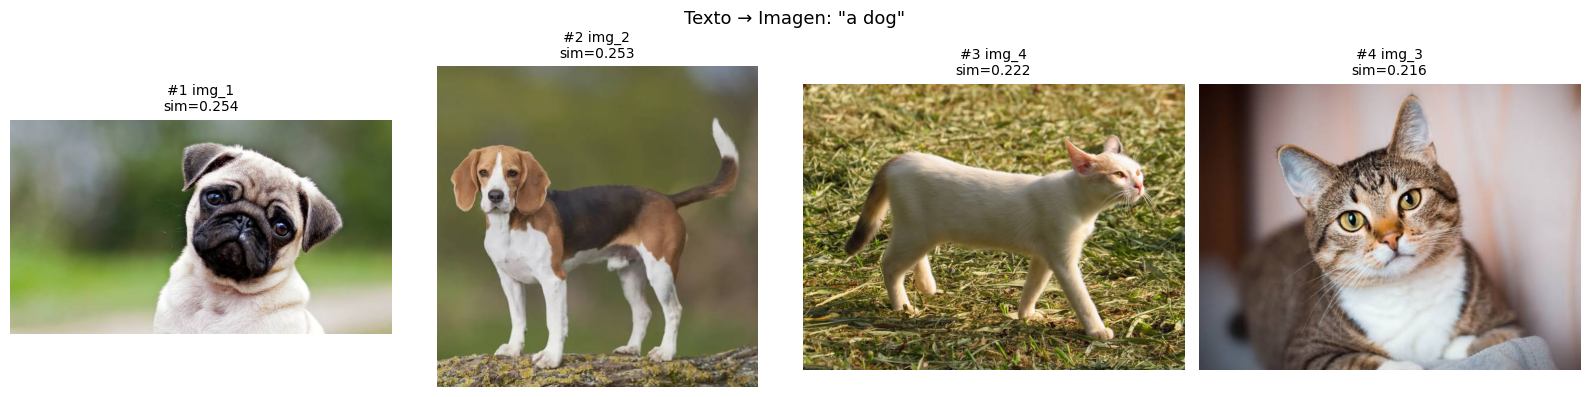

In [27]:
_ = buscar_imagenes("a dog", embs_img, modelo, tokenizer, imagenes)

### Consulta 2: "a cat sitting"

Ahora buscamos gatos. La img_3 es un gato atigrado sentado y la img_4 es un gato blanco caminando. Veamos si CLIP distingue la pose — "sitting" debería favorecer a img_3.

Query: "a cat sitting"

  img_3: sim=0.2624  prob=74.7% █████████████████████████████████████
  img_4: sim=0.2515  prob=25.0% ████████████
  img_1: sim=0.2032  prob=0.2% 
  img_6: sim=0.1905  prob=0.1% 
  img_5: sim=0.1797  prob=0.0% 
  img_2: sim=0.1753  prob=0.0% 
  img_8: sim=0.1749  prob=0.0% 
  img_7: sim=0.1605  prob=0.0% 
  img_10: sim=0.1538  prob=0.0% 
  img_9: sim=0.1481  prob=0.0% 


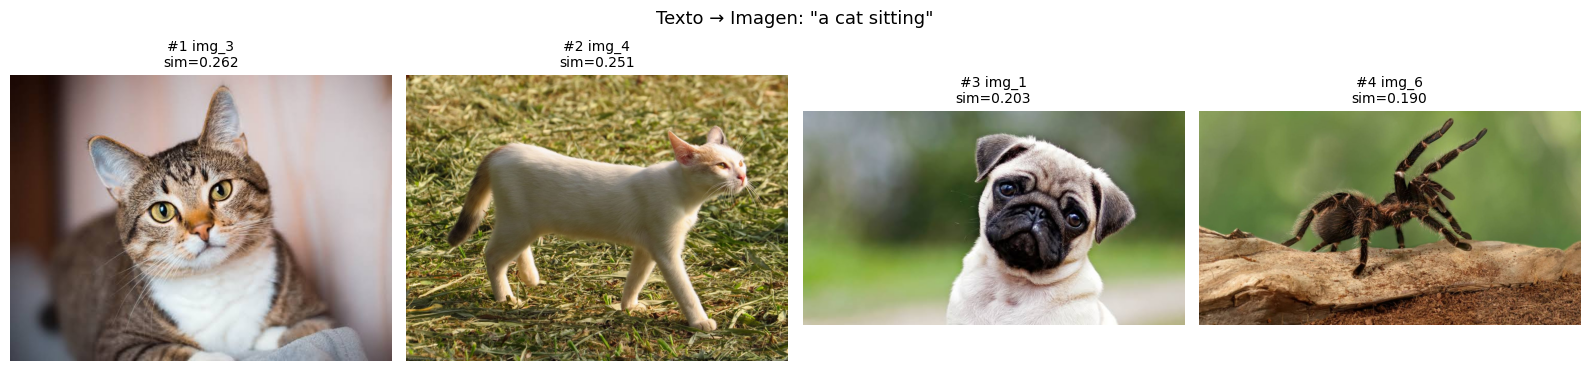

In [28]:
_ = buscar_imagenes("a cat sitting", embs_img, modelo, tokenizer, imagenes)

### Consulta 3: "flowers in nature"

Una consulta más general. Tenemos dos flores (img_7 loto y img_10 rosa). La consulta no especifica qué tipo de flor, así que ambas deberían rankear alto.

Query: "flowers in nature"

  img_7: sim=0.2641  prob=91.9% █████████████████████████████████████████████
  img_10: sim=0.2382  prob=6.9% ███
  img_5: sim=0.2190  prob=1.0% 
  img_9: sim=0.1970  prob=0.1% 
  img_8: sim=0.1737  prob=0.0% 
  img_4: sim=0.1726  prob=0.0% 
  img_2: sim=0.1670  prob=0.0% 
  img_3: sim=0.1620  prob=0.0% 
  img_6: sim=0.1619  prob=0.0% 
  img_1: sim=0.1586  prob=0.0% 


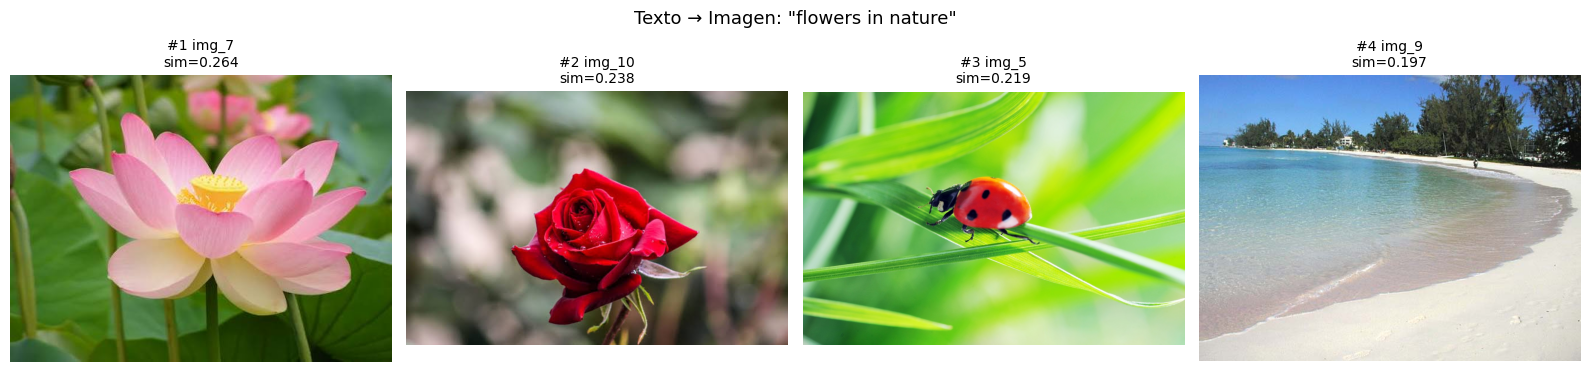

In [29]:
_ = buscar_imagenes("flowers in nature", embs_img, modelo, tokenizer, imagenes)

Observación: img_7 (loto) rankeó alto pero img_10 (rosa) no tanto como se esperaría. Esto puede deberse a que la foto de la rosa es un close-up de una sola flor con fondo borroso, mientras que "flowers in nature" sugiere un escenario más amplio y natural, que encaja mejor con la foto del loto rodeado de hojas verdes. CLIP no solo entiende el objeto sino también el contexto visual.

### Consulta 4: "a beach"

La img_9 es la única playa. Esperamos que salga claramente primera, ya que CLIP diferencia bien entre categorías muy distintas.

Query: "a beach"

  img_9: sim=0.2811  prob=99.9% █████████████████████████████████████████████████
  img_8: sim=0.2100  prob=0.1% 
  img_5: sim=0.1780  prob=0.0% 
  img_2: sim=0.1767  prob=0.0% 
  img_4: sim=0.1762  prob=0.0% 
  img_1: sim=0.1757  prob=0.0% 
  img_7: sim=0.1720  prob=0.0% 
  img_3: sim=0.1695  prob=0.0% 
  img_6: sim=0.1691  prob=0.0% 
  img_10: sim=0.1622  prob=0.0% 


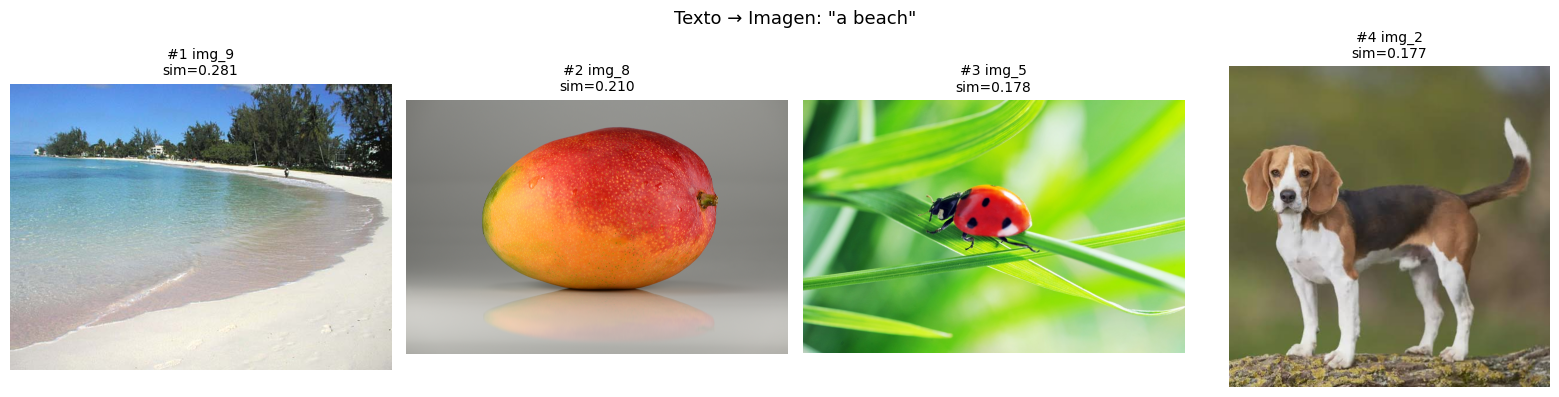

In [30]:
_ = buscar_imagenes("a beach", embs_img, modelo, tokenizer, imagenes)

## 7. Búsqueda imagen → texto (Paso 4 - dirección inversa)

Ahora al revés: dada una imagen, buscamos cuál de los textos la describe mejor. Esto es posible **solo porque** ambos viven en el mismo espacio vectorial, podemos calcular similitud en ambas direcciones.

In [31]:
def buscar_textos(nombre_img, embs_img, embs_txt, imagenes):
    vec_img = embs_img[nombre_img]
    
    textos_lista = list(embs_txt.keys())
    sims = np.array([np.dot(vec_img, embs_txt[t]) for t in textos_lista])
    
    ranking = sorted(zip(textos_lista, sims), key=lambda x: x[1], reverse=True)
    
    # mostrar la imagen a la izquierda y el ranking a la derecha
    fig, (ax_img, ax_txt) = plt.subplots(1, 2, figsize=(12, 4),
                                          gridspec_kw={"width_ratios": [1, 2]})
    ax_img.imshow(imagenes[nombre_img])
    ax_img.set_title(nombre_img, fontsize=12)
    ax_img.axis("off")
    
    # barras horizontales con las similitudes
    textos_r = [t for t, s in ranking]
    sims_r = [s for t, s in ranking]
    colores = ["#e74c3c" if i == 0 else "#3498db" for i in range(len(ranking))]
    
    ax_txt.barh(range(len(textos_r)), sims_r, color=colores)
    ax_txt.set_yticks(range(len(textos_r)))
    ax_txt.set_yticklabels([f'"{t}"' for t in textos_r], fontsize=9)
    ax_txt.set_xlabel("Similitud coseno")
    ax_txt.set_title("Imagen → Texto: ranking de descripciones", fontsize=12)
    ax_txt.invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Mejor match para {nombre_img}: \"{ranking[0][0]}\" (sim={ranking[0][1]:.4f})")
    return ranking

### img_1 (pug)

Dada la foto del pug, el texto más cercano debería ser "a pug dog". Es interesante ver si "a beagle standing" también rankea alto por ser un perro.

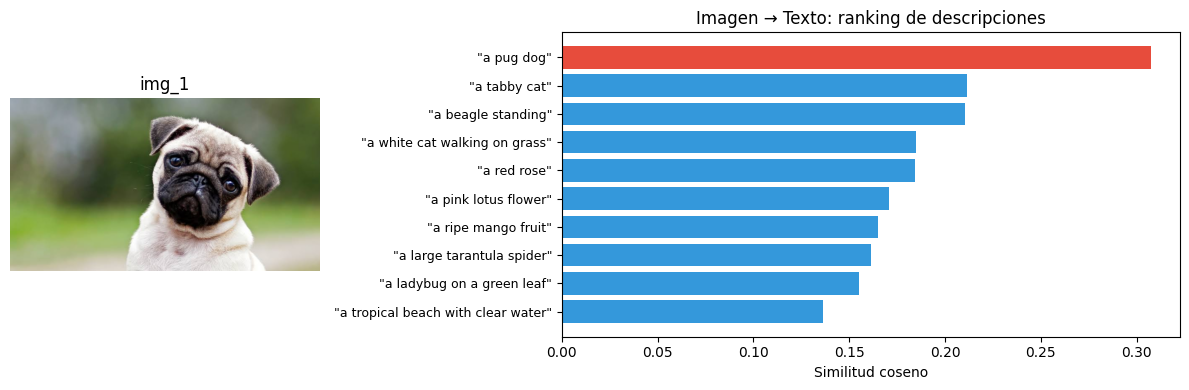

Mejor match para img_1: "a pug dog" (sim=0.3072)


In [32]:
# el pug
_ = buscar_textos("img_1", embs_img, embs_txt, imagenes)

"a pug dog" salió primero como se esperaba. Sin embargo "a tabby cat" aparece segundo, lo cual parece raro. Esto pasa porque ambas fotos son retratos frontales de animales domésticos pequeños con encuadre similar, CLIP captura ese patrón visual compartido (animal pequeño, cara de frente, fondo borroso) además del contenido semántico.

### img_5 (catarina)

La mariquita es un insecto. El texto "a ladybug on a green leaf" debería ser el mejor match. Veamos si "a large tarantula spider" tiene similitud alta por ser también un artrópodo.

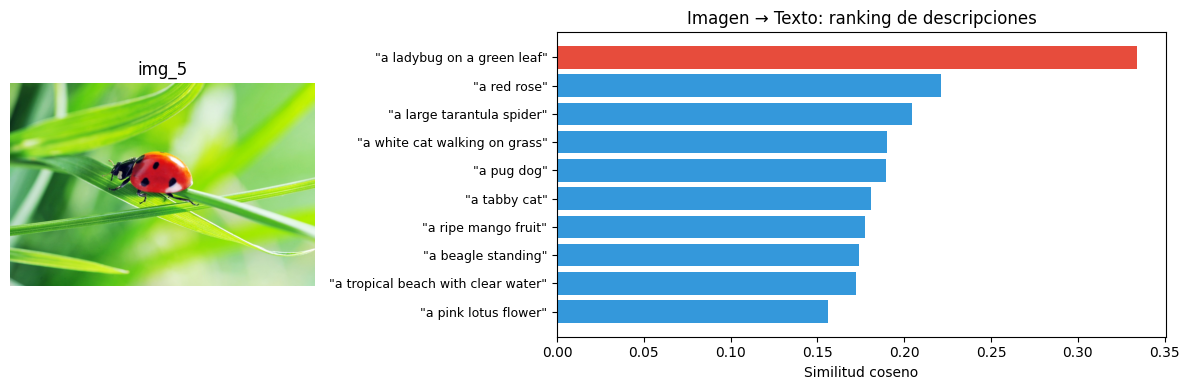

Mejor match para img_5: "a ladybug on a green leaf" (sim=0.3340)


In [ ]:
# la mariquita / ladybug
_ = buscar_textos("img_5", embs_img, embs_txt, imagenes)

### img_9 (playa)

La playa es una categoría muy distinta al resto. Esperamos que "a tropical beach with clear water" destaque claramente sobre los demás textos.

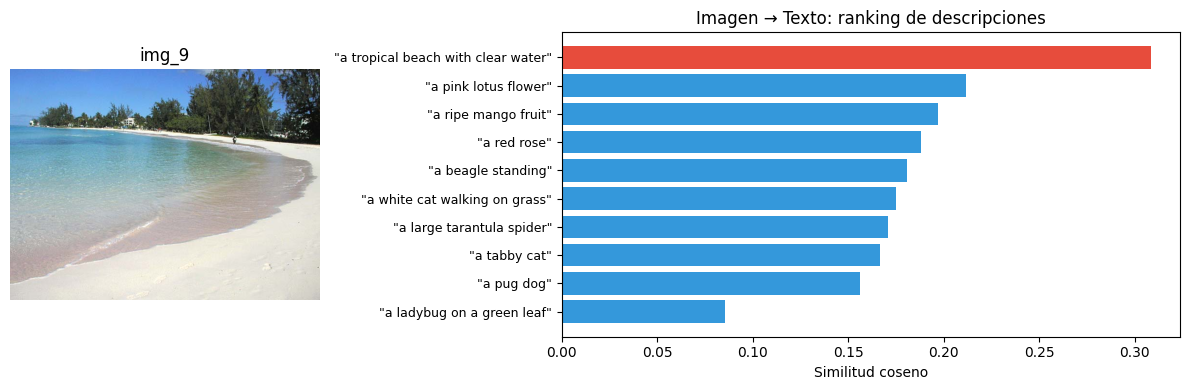

Mejor match para img_9: "a tropical beach with clear water" (sim=0.3084)


In [34]:
# la playa
_ = buscar_textos("img_9", embs_img, embs_txt, imagenes)

### img_8 (mango)

El mango es la única fruta. "a ripe mango fruit" debería ganar por bastante, ya que ningún otro texto describe comida.

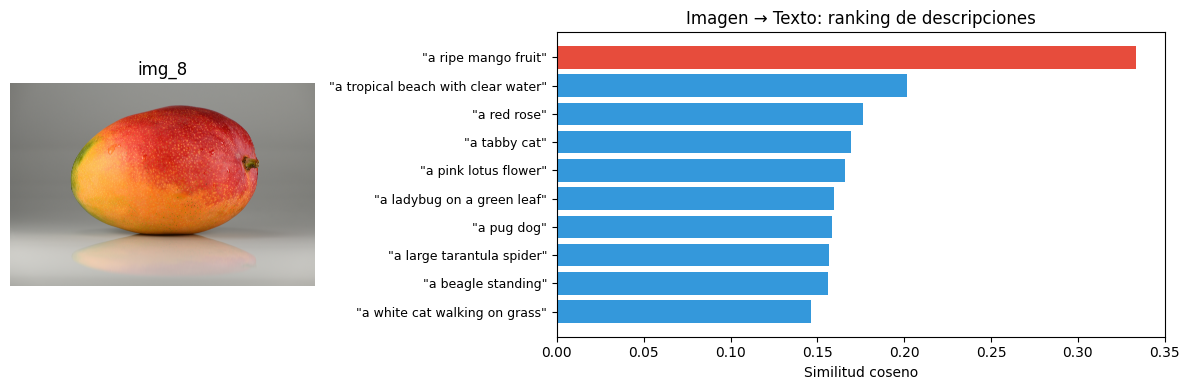

Mejor match para img_8: "a ripe mango fruit" (sim=0.3335)


In [35]:
# el mango
_ = buscar_textos("img_8", embs_img, embs_txt, imagenes)

## 8. Conclusiones

- CLIP proyecta texto e imágenes al **mismo espacio vectorial** de 512 dimensiones, lo que permite compararlos directamente con similitud coseno.
- Las proyecciones 2D (PCA, t-SNE) permiten visualizar que elementos relacionados tienden a agruparse, aunque con pocas muestras los clusters no siempre son evidentes.
- El heatmap de similitud muestra claramente cómo cada texto tiene mayor afinidad con su imagen correspondiente (la diagonal tiende a ser la más alta).
- La búsqueda funciona en **ambas direcciones**: texto→imagen e imagen→texto, confirmando que el espacio es realmente compartido.
- Esto resuelve el **semantic gap**: podemos buscar contenido visual usando lenguaje natural, sin necesitar etiquetas manuales.